<h1>Random Forest</h1>

<h2>Definition</h2>
<p>
Random Forest is an ensemble learning algorithm that combines multiple
decision trees to improve accuracy and reduce overfitting.
</p>

<h2>Working</h2>
<ol>
    <li>Randomly sample data</li>
    <li>Create multiple decision trees</li>
    <li>Use random features at each split</li>
    <li>Combine predictions of all trees</li>
</ol>

<h2>Advantages</h2>
<ul>
    <li>High accuracy</li>
    <li>Reduces overfitting</li>
    <li>Handles nonlinear data</li>
</ul>

<h2>Disadvantages</h2>
<ul>
    <li>Slow training</li>
    <li>High memory usage</li>
</ul>

<h2>Important Parameters</h2>
<ul>
    <li>n_estimators</li>
    <li>max_depth</li>
    <li>max_features</li>
</ul>

<h2>Python Example</h2>

<pre>
<code>
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
</code>
</pre>



## Making random forest from scratch

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.tree import plot_tree
import numpy as np

In [134]:
# creating 1000 rows data
X,y=make_classification(n_features=5,n_samples=1000,n_redundant=0,n_informative=5,n_clusters_per_class=1)


In [135]:
# converting into dataframe
import pandas as pd
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y

In [136]:
# sampling rows
# df.sample(
#     n=None,
#     frac=None,
#     replace=False,
#     weights=None,
#     random_state=None,
#     axis=None,
#     ignore_index=False
# )

# sampling functions to feed diff data to diff dts
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

import random

# colums sampling 
def sample_columns(df,percent):
    return df[random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]-1))]

sample_columns(df,0.3)

# combined sampling
def combined_sampling(df,row_per,col_per):
    new_df=sample_rows(df,row_per)
    return sample_columns(new_df,col_per)

In [137]:
df1=sample_rows(df,0.1)
df2=sample_rows(df,0.1)
df3=sample_rows(df,0.1)

In [138]:
dt1=DecisionTreeClassifier()
dt2=DecisionTreeClassifier()
dt3=DecisionTreeClassifier()

In [139]:
# fitting decision trees
X1=df1.iloc[:,0:5]
y1=df1.iloc[:,-1]
X2=df2.iloc[:,0:5]
y2=df2.iloc[:,-1]
X3=df3.iloc[:,0:5]
y3=df3.iloc[:,-1]
dt1.fit(X1,y1)
dt2.fit(X2,y2)
dt3.fit(X3,y3)

DecisionTreeClassifier()

[Text(0.53, 0.9375, 'x[4] <= 0.928\ngini = 0.498\nsamples = 100\nvalue = [53, 47]'),
 Text(0.22, 0.8125, 'x[1] <= -2.866\ngini = 0.425\nsamples = 62\nvalue = [19, 43]'),
 Text(0.375, 0.875, 'True  '),
 Text(0.08, 0.6875, 'x[2] <= 1.308\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.04, 0.5625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.12, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36, 0.6875, 'x[4] <= -0.56\ngini = 0.346\nsamples = 54\nvalue = [12, 42]'),
 Text(0.2, 0.5625, 'x[3] <= 1.205\ngini = 0.17\nsamples = 32\nvalue = [3, 29]'),
 Text(0.16, 0.4375, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.24, 0.4375, 'x[1] <= -0.368\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.16, 0.3125, 'x[0] <= -0.12\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.12, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.1875, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.32, 0.3125, 'x[3] <= 1.755\ngini = 0.165\nsamples = 11\nval

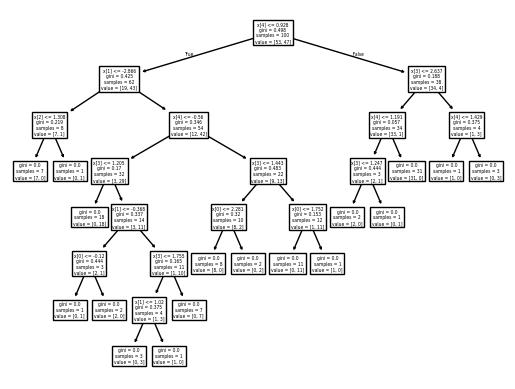

In [140]:
# plot trees
plot_tree(dt1)

[Text(0.6447368421052632, 0.9166666666666666, 'x[4] <= 0.822\ngini = 0.497\nsamples = 100\nvalue = [46, 54]'),
 Text(0.39473684210526316, 0.75, 'x[3] <= 1.74\ngini = 0.389\nsamples = 68\nvalue = [18, 50]'),
 Text(0.5197368421052632, 0.8333333333333333, 'True  '),
 Text(0.2631578947368421, 0.5833333333333334, 'x[4] <= -0.236\ngini = 0.214\nsamples = 41\nvalue = [5, 36]'),
 Text(0.15789473684210525, 0.4166666666666667, 'x[1] <= -2.547\ngini = 0.062\nsamples = 31\nvalue = [1, 30]'),
 Text(0.10526315789473684, 0.25, 'x[1] <= -2.799\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.05263157894736842, 0.08333333333333333, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.15789473684210525, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.21052631578947367, 0.25, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.3684210526315789, 0.4166666666666667, 'x[3] <= 0.542\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.3157894736842105, 0.25, 'gini = 0.0\nsample

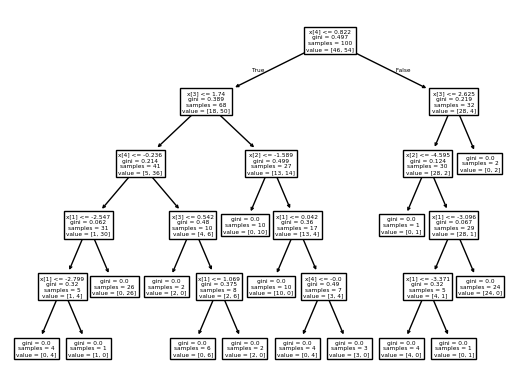

In [141]:
plot_tree(dt2)

[Text(0.49375, 0.95, 'x[4] <= 0.099\ngini = 0.499\nsamples = 100\nvalue = [52, 48]'),
 Text(0.2875, 0.85, 'x[2] <= -1.032\ngini = 0.411\nsamples = 52\nvalue = [15.0, 37.0]'),
 Text(0.390625, 0.8999999999999999, 'True  '),
 Text(0.15, 0.75, 'x[3] <= 0.825\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.1, 0.65, 'x[4] <= -1.04\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.05, 0.55, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.15, 0.55, 'x[3] <= 0.549\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.1, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2, 0.45, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2, 0.65, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.425, 0.75, 'x[4] <= -2.349\ngini = 0.491\nsamples = 30\nvalue = [13, 17]'),
 Text(0.375, 0.65, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.475, 0.65, 'x[0] <= -0.44\ngini = 0.499\nsamples = 25\nvalue = [13, 12]'),
 Text(0.35, 0.55, 'x[1] <= 0.757\ngini = 0.32\nsamples = 5\nval

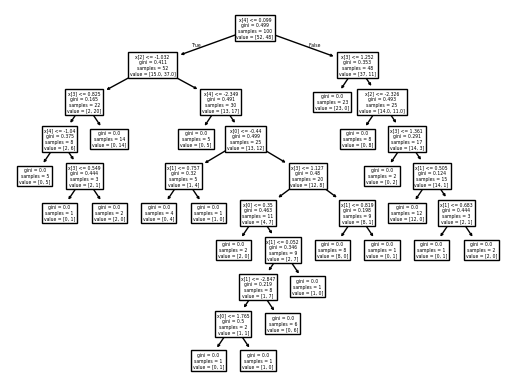

In [142]:
plot_tree(dt3)

In [143]:
# predicting results of various trees
res1=dt1.predict(np.array([[1.141842,	-0.042998,	1.239726,	3.291883,	-1.455112	]]))
res2=dt2.predict(np.array([[1.141842,	-0.042998,	1.239726,	3.291883,	-1.455112	]]))
res3=dt3.predict(np.array([[1.141842,	-0.042998,	1.239726,	3.291883,	-1.455112	]]))
print(res1,res2,res3)
# final result will be mode of above 3 results

[1] [0] [0]


c:\Users\mysel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\mysel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\mysel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [158]:
df = pd.read_csv("heart.csv")
X=df.iloc[0:130,0:-1]
y=df.iloc[0:130,-1]

In [180]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

model=RandomForestClassifier(oob_score=True)

param_grid={
    'n_estimators':[100,200,300,500],
    'max_samples':[.2,0.3,0.4,0.8],
    'max_features':[.2,.3,.5],
    'criterion':['gini','entropy'],
    'max_depth':[2,8,None]
}
gs=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,verbose=2,n_jobs=-1)
gs.fit(X,y)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(oob_score=True), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.3, 0.5],
                         'max_samples': [0.2, 0.3, 0.4, 0.8],
                         'n_estimators': [100, 200, 300, 500]},
             verbose=2)

In [166]:
best_model=gs.best_estimator_
pred=best_model.predict(df.iloc[131:260,0:-1])
from sklearn.metrics import accuracy_score
accuracy_score(pred,df.iloc[131:260,-1])

0.8527131782945736

[Text(0.5555555555555556, 0.9166666666666666, 'x[11] <= 0.5\ngini = 0.473\nsamples = 24\nvalue = [10, 16]'),
 Text(0.3333333333333333, 0.75, 'x[4] <= 283.0\ngini = 0.346\nsamples = 16\nvalue = [4, 14]'),
 Text(0.4444444444444444, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'x[4] <= 207.0\ngini = 0.231\nsamples = 13\nvalue = [2, 13]'),
 Text(0.16666666666666666, 0.4166666666666667, 'x[12] <= 1.5\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.1111111111111111, 0.25, 'x[3] <= 131.5\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.05555555555555555, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.16666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2222222222222222, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.2777777777777778, 0.4166666666666667, 'gini = 0.0\nsamples = 8\nvalue = [0, 10]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[9] <= 0.6\ngini = 0.444\nsample

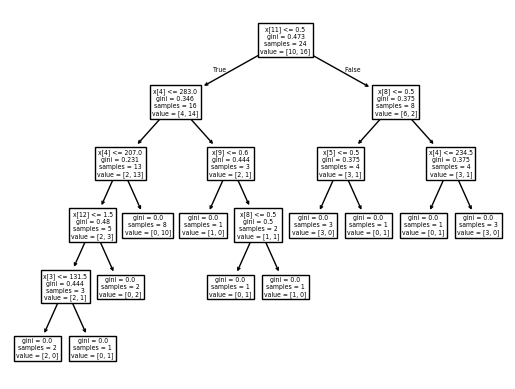

In [ ]:
from sklearn.tree import plot_tree
plot_tree(best_model.estimators_[0])